# AlphaSyndrome measurement schedules

A syndrome-measurement schedule decides the order in which ancillas touch data qubits.
That order changes how a single ancilla fault can spread, so schedules with the same checks can have different circuit-level logical error rates.

`AlphaSyndrome`, introduced in [arXiv:2601.12509](https://arxiv.org/abs/2601.12509), uses Monte Carlo tree search to choose a schedule for a supplied noise model and decoder.
The search is expensive; this notebook uses a small deterministic budget to demonstrate the API, not to reproduce the paper's optimization.


## Setup

Install the dependencies once in the environment that will run the notebook:

```bash
python -m pip install qldpc matplotlib
```


In [1]:
import os
from collections.abc import Sequence

import matplotlib.pyplot as plt
import numpy as np
import sinter

from qldpc import circuits, codes, decoders

NUM_WORKERS = max(1, min(4, (os.cpu_count() or 1) - 1))

In [2]:
def run_memory_experiments(
    code: codes.CSSCode,
    strategies: Sequence[circuits.SyndromeMeasurementStrategy],
    num_rounds: int,
    *,
    error_rates: Sequence[float] = tuple(np.logspace(-4, -2, 5)),
    max_shots: int = 20_000,
    max_errors: int = 100,
    **decoder_kwargs,
):
    tasks = []
    custom_decoders = {}

    for strategy_index, strategy in enumerate(strategies):
        parts = circuits.get_memory_experiment_parts(
            code,
            basis=None,
            num_rounds=num_rounds,
            syndrome_measurement_strategy=strategy,
        )
        detectors_x = parts.detector_record.get_events(*parts.qubit_ids.checks_x)
        detectors_z = parts.detector_record.get_events(*parts.qubit_ids.checks_z)

        decoder_name = f"strategy_{strategy_index}"
        custom_decoders[decoder_name] = decoders.SubgraphDecoder(
            (detectors_x, detectors_z),
            (range(code.dimension), range(code.dimension, 2 * code.dimension)),
            **decoder_kwargs,
        )

        for probability in error_rates:
            noise = circuits.DepolarizingNoiseModel(
                probability,
                include_idling_error=False,
            )
            noisy_circuit = (
                parts.initialization + noise.noisy_circuit(parts.qec_cycle) + parts.readout
            )
            tasks.append(
                sinter.Task(
                    circuit=noisy_circuit,
                    detector_error_model=noisy_circuit.detector_error_model(
                        decompose_errors=True,
                    ),
                    decoder=decoder_name,
                    json_metadata={
                        "label": type(strategy).__name__,
                        "probability": probability,
                    },
                )
            )

    return sinter.collect(
        tasks=tasks,
        custom_decoders=custom_decoders,
        num_workers=NUM_WORKERS,
        max_shots=max_shots,
        max_errors=max_errors,
        print_progress=False,
    )


def make_memory_experiment_figure(
    code,
    strategies,
    num_rounds,
    **decoder_kwargs,
):
    stats = run_memory_experiments(
        code,
        strategies,
        num_rounds,
        **decoder_kwargs,
    )
    figure, axis = plt.subplots(figsize=(5.5, 4.2))
    markers = ("o", "s", "^", "D")
    sinter.plot_error_rate(
        ax=axis,
        stats=stats,
        x_func=lambda stat: stat.json_metadata["probability"],
        group_func=lambda stat: stat.json_metadata["label"],
        plot_args_func=lambda index, _curve_id: {
            "marker": markers[index % len(markers)],
        },
    )
    physical_rates = sorted({stat.json_metadata["probability"] for stat in stats})
    axis.plot(
        physical_rates,
        physical_rates,
        color="black",
        linestyle=":",
        label=r"$p_{\mathrm{logical}}=p_{\mathrm{physical}}$",
    )
    axis.loglog()
    axis.set_xlabel("physical error rate per operation")
    axis.set_ylabel("estimated logical error rate")
    axis.set_title("Schedule comparison on the Steane code")
    axis.legend(loc="best")
    axis.grid(which="both", alpha=0.3)
    figure.tight_layout()
    return figure, axis

## A bounded Steane-code comparison

The search is trained at physical error rate `0.01`, the largest rate in the plotted sweep, so faults are common enough for the small search budget to see.
The seed fixes the random rollout choices, but Stim's evaluation samples are independently random, so repeated runs can still choose different schedules.
The reduced iteration and shot counts keep the example suitable for documentation.

MWPM is used only to keep this demo small.
The Steane detector model is not fully graphlike, `ignore_non_graphlike_errors=True` discards unsupported correlations, and this decoder does not establish a Steane-code threshold.


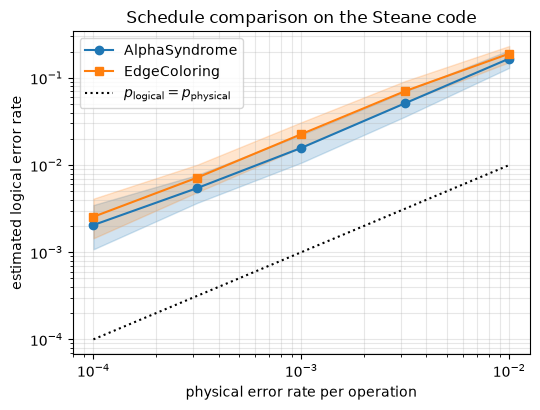

In [3]:
code = codes.SteaneCode()
decoding_kwargs = dict(with_MWPM=True, ignore_non_graphlike_errors=True)

noise_model = circuits.DepolarizingNoiseModel(10e-3)  # noise model used to train AlphaSyndrome
decoder = decoders.SinterDecoder(**decoding_kwargs)
strategies = [
    circuits.EdgeColoring(),
    circuits.AlphaSyndrome(
        noise_model,
        decoder=decoder,
        iters_per_step=30,
        shots_per_iter=2_000,
        verbose=False,
        seed=0,
    ),
]

make_memory_experiment_figure(code, strategies, num_rounds=3, **decoding_kwargs)
plt.show()

The plot compares one bounded search with the default edge-coloring schedule under the stated approximation.
If the learned curve is lower at a sampled point, that is evidence for this run—not a proof that the schedule is globally optimal or uniformly better.
